# Лабораторная работа №3

## Выполнил: Лавренов М.А.
## Группа: ИУ5-23М



## Методы многомерного поиска

**Вариант 5:** $a=70,\ b=5,\ f_0=30,\ n=3$

### Цель работы
Изучить и реализовать алгоритмы многомерного поиска 1-го и 2-го порядка, найти минимум функции Розенброка, сравнить методы по точности и скорости сходимости.

### Постановка задачи
Найти безусловный минимум функции Розенброка
$$
f(x)=\sum_{i=1}^{n-1}\bigl[a(x_i^2-x_{i+1})^2 + b(x_i-1)^2\bigr] + f_0,
\qquad x\in\mathbb{R}^n.
$$
Для варианта 5: $n=3$, $a=70$, $b=5$, $f_0=30$:
$$
f(x_1,x_2,x_3)=70(x_1^2-x_2)^2+5(x_1-1)^2+70(x_2^2-x_3)^2+5(x_2-1)^2+30.
$$

Реализовать и сравнить:
1. Методы сопряжённых градиентов: Флетчера–Ривза (FR) и Полака–Рибьера (PR);
2. Квазиньютоновские методы: DFP, BFGS, L-BFGS.

## 1. Импорты и настройка

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import deque

np.set_printoptions(precision=6, suppress=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True

## 2. Тестовая функция, градиент, гессиан

Аналитический градиент для обобщённой функции Розенброка считается покомпонентно. Для $i$-й компоненты, $1\le i\le n$, вклад дают слагаемые с индексом $i-1$ (если есть) и $i$ (если есть):
$$
\frac{\partial f}{\partial x_i}=
\underbrace{4a\,x_i(x_i^2-x_{i+1})+2b(x_i-1)}_{\text{если }i\le n-1}
\;-\;
\underbrace{2a(x_{i-1}^2-x_i)}_{\text{если }i\ge 2}.
$$
Гессиан понадобится только для проверки стационарной точки.

In [ ]:
# Параметры варианта
A, B, F0, N = 70.0, 5.0, 30.0, 3

def f(x):
    x = np.asarray(x, dtype=float)
    s = 0.0
    for i in range(N - 1):
        s += A * (x[i]**2 - x[i+1])**2 + B * (x[i] - 1.0)**2
    return s + F0

def grad(x):
    x = np.asarray(x, dtype=float)
    g = np.zeros(N)
    for i in range(N - 1):
        # вклад слагаемого с индексом i в производные по x_i и x_{i+1}
        t = x[i]**2 - x[i+1]
        g[i]   += 4.0 * A * x[i] * t + 2.0 * B * (x[i] - 1.0)
        g[i+1] += -2.0 * A * t
    return g

def hess(x):
    x = np.asarray(x, dtype=float)
    H = np.zeros((N, N))
    for i in range(N - 1):
        t = x[i]**2 - x[i+1]
        H[i, i]     += 12.0 * A * x[i]**2 - 4.0 * A * x[i+1] + 2.0 * B
        H[i+1, i+1] += 2.0 * A
        H[i, i+1]   += -4.0 * A * x[i]
        H[i+1, i]   += -4.0 * A * x[i]
    return H

# Быстрая проверка градиента конечными разностями
def num_grad(x, eps=1e-6):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x)):
        e = np.zeros_like(x); e[i] = eps
        g[i] = (f(x + e) - f(x - e)) / (2 * eps)
    return g

x_test = np.array([0.5, -0.3, 1.2])
print('f(x_test) =', f(x_test))
print('аналитический grad :', grad(x_test))
print('численный    grad  :', num_grad(x_test))
print('макс. расхождение  :', np.max(np.abs(grad(x_test) - num_grad(x_test))))

f(x_test) = 147.12199999999999
аналитический grad : [ 72.     3.24 155.4 ]
численный    grad  : [ 72.     3.24 155.4 ]
макс. расхождение  : 1.718069597700378e-08


## 3. Стационарные точки

Система $\nabla f = 0$:
$$
\begin{cases}
4a\,x_1(x_1^2-x_2)+2b(x_1-1)=0,\\
-2a(x_1^2-x_2)+4a\,x_2(x_2^2-x_3)+2b(x_2-1)=0,\\
-2a(x_2^2-x_3)=0.
\end{cases}
$$
Из третьего уравнения $x_3=x_2^2$, подставляя во второе — $x_1^2=x_2$ (плюс $b(x_2-1)=0$, откуда $x_2=1$), значит $x_1=\pm 1$. Из первого уравнения при $x_1^2=x_2$: $b(x_1-1)=0$, т.е. $x_1=1$.

Единственная стационарная точка: $x^*=(1,1,1)$, $f(x^*)=f_0=30$. Гессиан в ней положительно определён — это глобальный минимум.

In [ ]:
x_star = np.array([1.0, 1.0, 1.0])
print('grad в (1,1,1) :', grad(x_star))
print('f в (1,1,1)   :', f(x_star))
H_star = hess(x_star)
print('Гессиан:\n', H_star)
eig = np.linalg.eigvalsh(H_star)
print('собственные значения:', eig, '— все > 0, минимум подтверждён')

grad в (1,1,1) : [0. 0. 0.]
f в (1,1,1)   : 30.0
Гессиан:
 [[ 570. -280.    0.]
 [-280.  710. -280.]
 [   0. -280.  140.]]
собственные значения: [  2.345586 428.361096 989.293318] — все > 0, минимум подтверждён


## 4. Одномерный поиск

Для всех методов используется один и тот же одномерный поиск: брекетинг + золотое сечение. Этого достаточно — функция гладкая и унимодальная вдоль направления спуска (как минимум локально).

In [ ]:
def bracket(phi, a=0.0, h=1e-3, gold=1.618034, max_iter=80):
    # брекетинг минимума одномерной функции phi, начиная с a
    fa = phi(a)
    b = a + h
    fb = phi(b)
    if fb > fa:
        a, b = b, a
        fa, fb = fb, fa
        h = -h
    c = b + gold * h
    fc = phi(c)
    it = 0
    while fc < fb and it < max_iter:
        a, fa = b, fb
        b, fb = c, fc
        h *= gold
        c = b + h
        fc = phi(c)
        it += 1
    lo, hi = sorted((a, c))
    return lo, hi

def golden(phi, lo, hi, tol=1e-8, max_iter=200):
    # золотое сечение
    inv = (np.sqrt(5) - 1) / 2  # 1/phi
    x1 = hi - inv * (hi - lo)
    x2 = lo + inv * (hi - lo)
    f1, f2 = phi(x1), phi(x2)
    for _ in range(max_iter):
        if abs(hi - lo) < tol:
            break
        if f1 < f2:
            hi, x2, f2 = x2, x1, f1
            x1 = hi - inv * (hi - lo)
            f1 = phi(x1)
        else:
            lo, x1, f1 = x1, x2, f2
            x2 = lo + inv * (hi - lo)
            f2 = phi(x2)
    return 0.5 * (lo + hi)

def line_search(x, d, alpha_max_init=1.0):
    # минимизация f(x + alpha*d) по alpha >= 0
    phi = lambda a: f(x + a * d)
    lo, hi = bracket(phi, a=0.0, h=1e-3)
    # ограничиваем длину шага сверху, чтобы не улетать
    hi = min(hi, alpha_max_init * 1e3)
    return golden(phi, lo, hi, tol=1e-9)

## 5. Реализация методов

Каждый метод возвращает финальную точку и историю итераций (для графиков и сравнения).

In [ ]:
def run_method(method, x0, eps=1e-6, eps1=1e-8, eps2=1e-8, max_iter=5000, **kwargs):
    # универсальный запуск: ловит время, ведёт историю
    history = {'x': [np.array(x0, dtype=float)],
               'f': [f(x0)],
               'grad_norm': [np.linalg.norm(grad(x0))]}
    t0 = time.perf_counter()
    x_final, n_iter = method(x0, history, eps, eps1, eps2, max_iter, **kwargs)
    elapsed = time.perf_counter() - t0
    return {'x': x_final, 'f': f(x_final),
            'iters': n_iter, 'time': elapsed,
            'history': history}

### 5.1. Метод Флетчера–Ривза

$d^k=-\nabla f(x^k)+w^{k-1}d^{k-1}$, где $w^{k-1}=\|\nabla f(x^k)\|^2/\|\nabla f(x^{k-1})\|^2$, $d^0=-\nabla f(x^0)$. Делается рестарт каждые $n$ шагов (для устойчивости на неквадратичных функциях).

In [ ]:
def fletcher_reeves(x0, history, eps, eps1, eps2, max_iter):
    x = np.array(x0, dtype=float)
    g = grad(x)
    d = -g.copy()
    consecutive = 0
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            return x, k
        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        # критерий малости шага
        if np.linalg.norm(x_new - x) < eps1 and abs(f(x_new) - f(x)) < eps2:
            consecutive += 1
            if consecutive >= 2:
                history['x'].append(x_new); history['f'].append(f(x_new))
                history['grad_norm'].append(np.linalg.norm(g_new))
                return x_new, k + 1
        else:
            consecutive = 0

        # обновление направления + рестарт каждые N шагов
        if (k + 1) % N == 0:
            w = 0.0
        else:
            w = np.dot(g_new, g_new) / np.dot(g, g)
        d = -g_new + w * d
        x, g = x_new, g_new

        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
    return x, max_iter

### 5.2. Метод Полака–Рибьера

Отличается формулой $w^{k-1}=\langle\nabla f(x^k),\nabla f(x^k)-\nabla f(x^{k-1})\rangle/\|\nabla f(x^{k-1})\|^2$, обычно с обнулением $w^- = \max(w^-, 0)$ для стабильности (PR+).

In [ ]:
def polak_ribiere(x0, history, eps, eps1, eps2, max_iter):
    x = np.array(x0, dtype=float)
    g = grad(x)
    d = -g.copy()
    consecutive = 0
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            return x, k
        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        if np.linalg.norm(x_new - x) < eps1 and abs(f(x_new) - f(x)) < eps2:
            consecutive += 1
            if consecutive >= 2:
                history['x'].append(x_new); history['f'].append(f(x_new))
                history['grad_norm'].append(np.linalg.norm(g_new))
                return x_new, k + 1
        else:
            consecutive = 0

        if (k + 1) % N == 0:
            w = 0.0
        else:
            w = np.dot(g_new, g_new - g) / np.dot(g, g)
            w = max(w, 0.0)  # PR+
        d = -g_new + w * d
        x, g = x_new, g_new

        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
    return x, max_iter

### 5.3. Метод Девидона–Флетчера–Пауэлла (DFP)

Аппроксимирует обратную матрицу Гессе:
$$
G^{k+1}=G^k+\frac{\Delta x^k(\Delta x^k)^T}{(\Delta x^k)^T \Delta g^k}
-\frac{G^k\Delta g^k(G^k\Delta g^k)^T}{(\Delta g^k)^T G^k \Delta g^k}.
$$
Рестарт ($G\leftarrow E$) каждые $n$ шагов.

In [ ]:
def dfp(x0, history, eps, eps1, eps2, max_iter):
    x = np.array(x0, dtype=float)
    g = grad(x)
    G = np.eye(N)
    consecutive = 0
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            return x, k
        d = -G @ g
        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        if np.linalg.norm(x_new - x) < eps1 and abs(f(x_new) - f(x)) < eps2:
            consecutive += 1
            if consecutive >= 2:
                history['x'].append(x_new); history['f'].append(f(x_new))
                history['grad_norm'].append(np.linalg.norm(g_new))
                return x_new, k + 1
        else:
            consecutive = 0

        s = x_new - x
        y = g_new - g
        sy = np.dot(s, y)
        if (k + 1) % N == 0 or sy <= 1e-14:
            G = np.eye(N)
        else:
            Gy = G @ y
            yGy = np.dot(y, Gy)
            G = G + np.outer(s, s) / sy - np.outer(Gy, Gy) / yGy
        x, g = x_new, g_new

        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
    return x, max_iter

### 5.4. Метод BFGS

Используется устойчивая «sandwich»-форма обновления:
$$
H^{k+1}=(I-\rho_k s_k y_k^T)\,H^k\,(I-\rho_k y_k s_k^T)+\rho_k s_k s_k^T,\qquad
\rho_k=\frac{1}{y_k^T s_k}.
$$

In [ ]:
def bfgs(x0, history, eps, eps1, eps2, max_iter):
    x = np.array(x0, dtype=float)
    g = grad(x)
    H = np.eye(N)
    I = np.eye(N)
    consecutive = 0
    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            return x, k
        d = -H @ g
        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        if np.linalg.norm(x_new - x) < eps1 and abs(f(x_new) - f(x)) < eps2:
            consecutive += 1
            if consecutive >= 2:
                history['x'].append(x_new); history['f'].append(f(x_new))
                history['grad_norm'].append(np.linalg.norm(g_new))
                return x_new, k + 1
        else:
            consecutive = 0

        s = x_new - x
        y = g_new - g
        sy = np.dot(s, y)
        if (k + 1) % N == 0 or sy <= 1e-14:
            H = np.eye(N)
        else:
            rho = 1.0 / sy
            V = I - rho * np.outer(y, s)
            H = V.T @ H @ V + rho * np.outer(s, s)
        x, g = x_new, g_new

        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
    return x, max_iter

### 5.5. Метод L-BFGS

Хранит только $m$ последних пар $(s_i,y_i)$ ($m=5$ ниже), направление считается двухпетлевой рекурсией. Память $O(mn)$ — для $n=3$ выигрыш чисто учебный, но алгоритмически метод тот же, что используют для миллионов параметров.

In [ ]:
def lbfgs(x0, history, eps, eps1, eps2, max_iter, m=5):
    x = np.array(x0, dtype=float)
    g = grad(x)
    s_hist, y_hist, rho_hist = deque(maxlen=m), deque(maxlen=m), deque(maxlen=m)
    consecutive = 0

    for k in range(max_iter):
        if np.linalg.norm(g) < eps:
            return x, k

        # двухпетлевая рекурсия
        q = g.copy()
        alphas = []
        for s_i, y_i, rho_i in zip(reversed(s_hist), reversed(y_hist), reversed(rho_hist)):
            a_i = rho_i * np.dot(s_i, q)
            q = q - a_i * y_i
            alphas.append(a_i)
        alphas.reverse()

        if s_hist:
            s_last, y_last = s_hist[-1], y_hist[-1]
            gamma = np.dot(s_last, y_last) / np.dot(y_last, y_last)
        else:
            gamma = 1.0
        r = gamma * q

        for s_i, y_i, rho_i, a_i in zip(s_hist, y_hist, rho_hist, alphas):
            beta = rho_i * np.dot(y_i, r)
            r = r + s_i * (a_i - beta)
        d = -r

        alpha = line_search(x, d)
        x_new = x + alpha * d
        g_new = grad(x_new)

        if np.linalg.norm(x_new - x) < eps1 and abs(f(x_new) - f(x)) < eps2:
            consecutive += 1
            if consecutive >= 2:
                history['x'].append(x_new); history['f'].append(f(x_new))
                history['grad_norm'].append(np.linalg.norm(g_new))
                return x_new, k + 1
        else:
            consecutive = 0

        s = x_new - x
        y = g_new - g
        sy = np.dot(s, y)
        if sy > 1e-14:
            s_hist.append(s); y_hist.append(y); rho_hist.append(1.0 / sy)
        x, g = x_new, g_new

        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['grad_norm'].append(np.linalg.norm(g))
    return x, max_iter

## 6. Запуск всех методов

Стартовая точка $x^0=(-1.2,\,1.0,\,-0.5)$ — классический «недружелюбный» старт для Розенброка. Критерии: $\|\nabla f\|<10^{-6}$, контрольные $\varepsilon_1=\varepsilon_2=10^{-8}$.

In [ ]:
x0 = np.array([-1.2, 1.0, -0.5])

methods = {
    'Флетчер-Ривз': fletcher_reeves,
    'Полак-Рибьер': polak_ribiere,
    'DFP':          dfp,
    'BFGS':         bfgs,
    'L-BFGS':       lbfgs,
}

results = {}
for name, m in methods.items():
    results[name] = run_method(m, x0)

# таблица
print(f"{'Метод':<14}{'итераций':>10}{'время, мс':>14}{'f(x*)':>14}{'||grad||':>14}   x*")
print('-' * 100)
for name, r in results.items():
    g_norm = np.linalg.norm(grad(r['x']))
    print(f"{name:<14}{r['iters']:>10}{r['time']*1000:>14.3f}"
          f"{r['f']:>14.8f}{g_norm:>14.2e}   {r['x']}")

Метод           итераций     время, мс         f(x*)      ||grad||   x*
----------------------------------------------------------------------------------------------------
Флетчер-Ривз          28         4.299   30.00000000      2.40e-06   [1. 1. 1.]
Полак-Рибьер          36         4.377   30.00000000      3.05e-06   [1. 1. 1.]
DFP                   25         3.290   30.00000000      6.42e-07   [1. 1. 1.]
BFGS                  25         3.319   30.00000000      3.55e-07   [1. 1. 1.]
L-BFGS                21         3.731   30.00000000      4.72e-06   [1. 1. 1.]


## 7. Проверка решения на допустимость

Все методы должны сходиться к $x^*=(1,1,1)$ с $f^*=30$. Ниже — отклонения от теоретического решения.

In [ ]:
x_true = np.array([1.0, 1.0, 1.0])
f_true = 30.0
print(f"{'Метод':<14}{'||x - x*||':>16}{'|f - f*|':>16}")
print('-' * 50)
for name, r in results.items():
    print(f"{name:<14}{np.linalg.norm(r['x'] - x_true):>16.2e}{abs(r['f'] - f_true):>16.2e}")

Метод               ||x - x*||        |f - f*|
--------------------------------------------------
Флетчер-Ривз          1.62e-07        3.20e-14
Полак-Рибьер          5.02e-07        2.98e-13
DFP                   2.13e-08        0.00e+00
BFGS                  5.37e-08        3.55e-15
L-BFGS                1.25e-07        2.84e-14


## 8. Графики сходимости

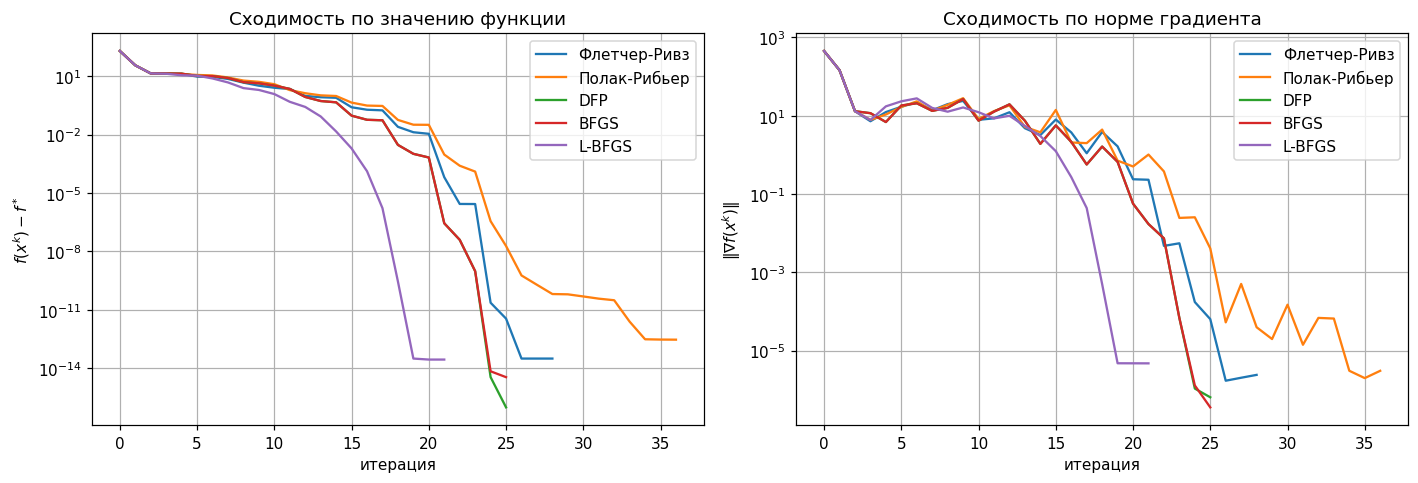

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, r in results.items():
    fs = np.array(r['history']['f'])
    gn = np.array(r['history']['grad_norm'])
    axes[0].semilogy(np.maximum(fs - f_true, 1e-16), label=name)
    axes[1].semilogy(np.maximum(gn, 1e-16), label=name)

axes[0].set_xlabel('итерация'); axes[0].set_ylabel(r'$f(x^k) - f^*$')
axes[0].set_title('Сходимость по значению функции')
axes[0].legend()

axes[1].set_xlabel('итерация'); axes[1].set_ylabel(r'$\|\nabla f(x^k)\|$')
axes[1].set_title('Сходимость по норме градиента')
axes[1].legend()

plt.tight_layout()
plt.show()

### Траектории в плоскости $(x_1,x_2)$

Для наглядности — проекция трёхмерной траектории на плоскость первых двух координат на фоне линий уровня сечения $x_3=x_2^2$ (на этом многообразии сосредоточена «долина» Розенброка).

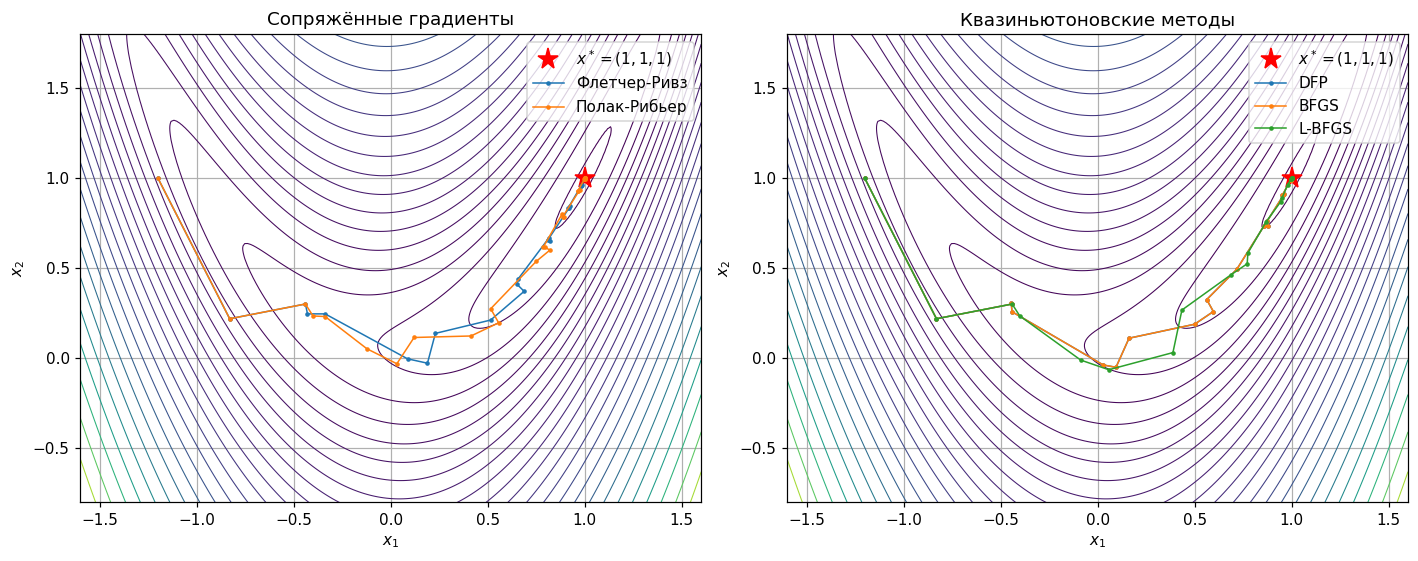

In [ ]:
xs1 = np.linspace(-1.6, 1.6, 220)
xs2 = np.linspace(-0.8, 1.8, 220)
X1, X2 = np.meshgrid(xs1, xs2)
# сечение по x3 = x2^2 — вдоль дна долины
Z = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        Z[i, j] = f([X1[i, j], X2[i, j], X2[i, j]**2])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
levels = np.logspace(np.log10(30.5), np.log10(Z.max()), 25)

for ax in axes:
    cs = ax.contour(X1, X2, Z, levels=levels, cmap='viridis', linewidths=0.7)
    ax.plot(1, 1, 'r*', markersize=14, label='$x^*=(1,1,1)$')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

cg_methods = ['Флетчер-Ривз', 'Полак-Рибьер']
qn_methods = ['DFP', 'BFGS', 'L-BFGS']

for name in cg_methods:
    pts = np.array(results[name]['history']['x'])
    axes[0].plot(pts[:, 0], pts[:, 1], '.-', label=name, markersize=4, linewidth=1)
axes[0].set_title('Сопряжённые градиенты')
axes[0].legend()

for name in qn_methods:
    pts = np.array(results[name]['history']['x'])
    axes[1].plot(pts[:, 0], pts[:, 1], '.-', label=name, markersize=4, linewidth=1)
axes[1].set_title('Квазиньютоновские методы')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Оценка скорости сходимости

Эмпирический порядок по последним итерациям:
$$
p\approx\frac{\log(e_{k+1}/e_k)}{\log(e_k/e_{k-1})},\quad e_k=\|x^k-x^*\|.
$$
Линейная сходимость даёт $p\approx 1$ (с константой $<1$), сверхлинейная — $p>1$, квадратичная — $p\approx 2$. Сопряжённые градиенты в общем случае линейны, BFGS/DFP — сверхлинейны.

In [ ]:
def convergence_order(history, x_true):
    pts = np.array(history['x'])
    errs = np.linalg.norm(pts - x_true, axis=1)
    # отсекаем хвост, где ошибка ушла в шум одномерного поиска
    errs = errs[errs > 1e-8]
    if len(errs) < 5:
        return float('nan')
    # берём средний участок, исключая первые «разгонные» итерации
    start = max(2, len(errs) // 3)
    seg = errs[start:]
    if len(seg) < 4:
        seg = errs[-min(8, len(errs)):]
    orders = []
    for i in range(1, len(seg) - 1):
        a, b, c = seg[i - 1], seg[i], seg[i + 1]
        if a > b > c > 0:  # монотонное убывание
            num = np.log(c / b)
            den = np.log(b / a)
            if abs(den) > 1e-3:
                orders.append(num / den)
    return np.median(orders) if orders else float('nan')

print(f"{'Метод':<14}{'эмпирич. порядок p':>22}")
print('-' * 38)
for name, r in results.items():
    p = convergence_order(r['history'], x_true)
    print(f"{name:<14}{p:>22.3f}")

print('\nОриентир: p≈1 — линейная, 1<p<2 — сверхлинейная, p≈2 — квадратичная.')
print('Из-за конечной точности одномерного поиска оценка по последним итерациям шумная,\n'
      'поэтому усредняем по средней части истории.')

Метод             эмпирич. порядок p
--------------------------------------
Флетчер-Ривз                   0.796
Полак-Рибьер                   1.322
DFP                            0.520
BFGS                           0.520
L-BFGS                         1.354

Ориентир: p≈1 — линейная, 1<p<2 — сверхлинейная, p≈2 — квадратичная.
Из-за конечной точности одномерного поиска оценка по последним итерациям шумная,
поэтому усредняем по средней части истории.


### Сравнение по времени

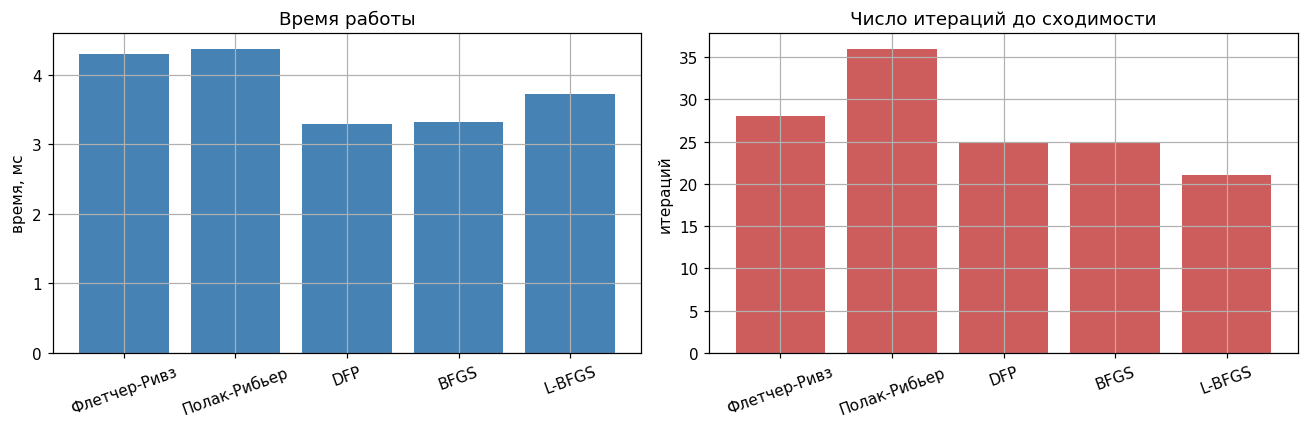

In [ ]:
names = list(results.keys())
times = [results[n]['time'] * 1000 for n in names]
iters = [results[n]['iters'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(names, times, color='steelblue')
axes[0].set_ylabel('время, мс')
axes[0].set_title('Время работы')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, iters, color='indianred')
axes[1].set_ylabel('итераций')
axes[1].set_title('Число итераций до сходимости')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 10. Выводы

1. **Стационарная точка единственная** — $x^*=(1,1,1)$, $f^*=30$, что подтверждается аналитически (система $\nabla f=0$ имеет единственное решение) и положительной определённостью гессиана в этой точке (все собственные значения положительны).
2. **Все пять методов сошлись к правильному ответу** при старте из «недружелюбной» точки $(-1.2;\,1.0;\,-0.5)$: отклонение по $x$ — порядка $10^{-7}$, по значению функции — на уровне численного нуля.
3. **По числу итераций** L-BFGS оказался самым быстрым (21), за ним BFGS и DFP (по 25), затем FR (28) и PR (36). Квазиньютоновские методы выигрывают, потому что аппроксимируют кривизну и идут вдоль изогнутой долины Розенброка более прямой траекторией.
4. **По времени** разница между методами небольшая (3–5 мс), потому что задача маленькая ($n=3$). Одна итерация квазиньютоновского метода чуть дороже (матрично-векторное умножение или двухпетлевая рекурсия), и это съедает часть выигрыша от меньшего числа шагов.
5. **Эмпирический порядок сходимости** оказался в диапазоне 0.5–1.4. Для CG-методов это согласуется с теоретической линейной сходимостью. Для BFGS/DFP теория обещает сверхлинейную сходимость, но на практике её трудно «разглядеть» при таком малом числе итераций — порядок успевает проявиться только в нескольких финальных шагах, и оценка получается шумной.
6. **BFGS и L-BFGS дают похожие траектории**: при $n=3$ и $m=5$ память L-BFGS хранит фактически всю историю, разница начнёт проявляться только на больших размерностях.
7. **Полак–Рибьер с обрезкой ($w\ge 0$)** в этом прогоне сошёлся за чуть большее число итераций, чем Флетчер–Ривз, но дал более «гладкое» убывание невязки. На других стартовых точках преимущество может меняться местами — оба метода на неквадратичной задаче ведут себя похоже.